# Griffiths Ch. 1 — Worked Solutions: 1.13, 1.14, 1.17, 1.21–1.25, 1.45–1.46

**Companion to** `griffiths_1p10_pseudovectors.ipynb` (Problem 1.10) and `griffiths_prep.ipynb` (the math Griffiths assumes).

The running theme: **inversion turns a right-handed frame into a left-handed one** — that single
"offense" (det $P = -1$) is what splits the world into vectors vs. pseudovectors and scalars vs.
pseudoscalars. Everything else in this chapter is the differential machinery (gradients of the
separation vector, product rules, $(\mathbf{A}\cdot\nabla)\mathbf{B}$) and the distributional
machinery ($\delta$, $\theta$) that electrodynamics runs on.

All symbolic work is done by the repo's **`griffiths` package** (`griffiths/vectors.py`,
`griffiths/parity.py`, `griffiths/deltas.py`) — the notebook just drives it and renders results
via `sympy.init_printing`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # repo root -> import griffiths

import sympy as sp
from sympy import Rational, oo
from IPython.display import display, Math, Markdown

import griffiths as gr
from griffiths import x, y, z, xp, yp, zp

sp.init_printing(use_latex="mathjax")   # every sympy object now renders as typeset math
print("griffiths package", gr.__version__)

griffiths package 0.1.0


## §1 Warm-up: why "right → left" is the whole story (Problem 1.10 recap)

Inversion $\;\bar x=-x,\ \bar y=-y,\ \bar z=-z\;$ is the matrix $P=-\mathbb{1}$ with
$\det P = -1$: an **improper** transformation. No rotation can undo it — it converts a
right-handed basis into a left-handed one. Objects are then classified by how they respond:

| object | example | sign under inversion |
|---|---|---|
| scalar | $\mathbf A\cdot\mathbf B$, mass | $+1$ |
| vector (polar) | $\mathbf r,\ \mathbf v,\ \mathbf E$ | $-1$ |
| pseudovector (axial) | $\mathbf L=\mathbf r\times\mathbf p,\ \mathbf B,\ \boldsymbol\tau,\ \boldsymbol\omega$ | $+1$ |
| pseudoscalar | $\mathbf A\cdot(\mathbf B\times\mathbf C)$ | $-1$ |

The cross product is "anomalous" because both factors flip sign and the two minus signs cancel —
it secretly carries the handedness convention of the frame inside it.

In [2]:
P = gr.parity_matrix()
display(Math(r"P = " + sp.latex(P) + r",\qquad \det P = " + sp.latex(P.det())))

basis = ([1, 0, 0], [0, 1, 0], [0, 0, 1])
inverted = tuple((-sp.Matrix(e)).T.tolist()[0] for e in basis)
print("original basis :", gr.handedness(*basis) + "-handed")
print("after inversion:", gr.handedness(*inverted) + "-handed   <- the 'offense'")

# cross product of two (inverted) vectors refuses to flip:
a1, a2, a3, b1, b2, b3 = sp.symbols("a1:4 b1:4", real=True)
A, B = sp.Matrix([a1, a2, a3]), sp.Matrix([b1, b2, b3])
display(Math(r"(-\mathbf A)\times(-\mathbf B) = " + sp.latex(((-A).cross(-B)).T)
             + r" = +(\mathbf A\times\mathbf B)\quad\Rightarrow\ \text{pseudovector}"))

<IPython.core.display.Math object>

original basis : right-handed
after inversion: left-handed   <- the 'offense'


<IPython.core.display.Math object>

## §2 Problem 1.13 — gradients of the separation vector

Let $\vec{\mathscr r} = (x-x')\hat x + (y-y')\hat y + (z-z')\hat z$ be the separation vector from
a fixed source point $(x',y',z')$ to the field point $(x,y,z)$, with length $\mathscr r$. Show:

**(a)** $\nabla(\mathscr r^2) = 2\vec{\mathscr r}$  **(b)** $\nabla(1/\mathscr r) = -\hat{\mathscr r}/\mathscr r^2$  **(c)** general formula for $\nabla(\mathscr r^n)$

(The footnote's *Beware* applies: $\vec{\mathscr r}$ is not $\mathbf r$ — it is anchored at the
source point, which is exactly why it shows up in every Coulomb/Green's-function integral.)

In [3]:
rvec = gr.separation_vector()           # field point minus source point
rlen = gr.separation_length()
display(Math(r"\vec{\mathscr{r}} = " + sp.latex(rvec.T) + r",\qquad \mathscr{r} = " + sp.latex(rlen)))

# (a) grad(r^2) -- gradient acts on the FIELD point (x,y,z); (x',y',z') are constants
computed, predicted = gr.grad_r_power(2)
display(Math(r"\nabla(\mathscr{r}^2) = " + sp.latex(sp.expand(computed).T)
             + r" = 2\,\vec{\mathscr{r}}"))
assert sp.simplify(computed - predicted) == sp.zeros(3, 1)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [4]:
# (b) grad(1/r) = -rhat / r^2
computed, predicted = gr.grad_r_power(-1)
display(Math(r"\nabla\!\left(\frac{1}{\mathscr{r}}\right) = " + sp.latex(computed.T)
             + r" = -\frac{\hat{\mathscr{r}}}{\mathscr{r}^{2}}"))
assert sp.simplify(computed - predicted) == sp.zeros(3, 1)

<IPython.core.display.Math object>

In [5]:
# (c) the general formula, proven for SYMBOLIC n:  grad(r^n) = n r^(n-1) rhat
n = sp.Symbol("n")
computed, predicted = gr.grad_r_power(n)
assert sp.simplify(computed - predicted) == sp.zeros(3, 1)
display(Math(r"\boxed{\ \nabla(\mathscr{r}^{\,n}) = n\,\mathscr{r}^{\,n-1}\,\hat{\mathscr{r}}\ }"
             + r"\quad\text{(a) is } n=2,\ \text{(b) is } n=-1"))

<IPython.core.display.Math object>

## §2b Problem 1.14 -- $\nabla f$ transforms as a vector

Suppose $f$ is a function of two variables $(y,z)$ only. Under a rotation
by angle $\phi$ in the $y$-$z$ plane,
$$\bar y = y\cos\phi + z\sin\phi,\qquad \bar z = -y\sin\phi + z\cos\phi.$$
Show that $\nabla f=(\partial f/\partial y)\hat y+(\partial f/\partial z)\hat z$
transforms the same way -- i.e. that $(\nabla f)_{\bar y}$ and $(\nabla f)_{\bar z}$
mix into each other via the SAME rotation matrix that mixes $\bar y,\bar z$
themselves. This is Griffiths defining what "being a vector" operationally
means: not "has an arrow drawn on it," but "transforms this way under a
change of frame" -- the one-time proof that licenses writing $\mathbf E=-\nabla V$
and trusting it holds for every observer, no matter how they oriented their axes.

Note: this section uses fresh symbols ($Y,Z,\bar Y,\bar Z,\phi$), NOT the
`x,y,z` imported from the `griffiths` package above -- Problem 1.14 is a
2-variable problem, unrelated to the 3D separation vector in §2.

**Step 1 -- invert the rotation.** Multiply the $\bar y$
equation by $\cos\phi$, the $\bar z$ equation by $\sin\phi$, and SUBTRACT
(the $Z$-terms already carry the same sign, so subtracting cancels them;
for solving $Z$ instead you'd multiply by $\sin\phi,\cos\phi$ and ADD,
since those $Y$-terms carry opposite signs from the start):

In [6]:
Y, Z, phi = sp.symbols('Y Z phi', real=True)
Ybar, Zbar = sp.symbols('Ybar Zbar', real=True)

eq_ybar = sp.Eq(Ybar, Y*sp.cos(phi) + Z*sp.sin(phi))
eq_zbar = sp.Eq(Zbar, -Y*sp.sin(phi) + Z*sp.cos(phi))
display(Math(sp.latex(eq_ybar) + r"\qquad" + sp.latex(eq_zbar)))

sol = sp.solve([eq_ybar, eq_zbar], [Y, Z])
Y_of_bar, Z_of_bar = sol[Y], sol[Z]
display(Math(r"Y = " + sp.latex(Y_of_bar) + r",\qquad Z = " + sp.latex(Z_of_bar)))

# verify this really is the inverse: substituting back reproduces Ybar, Zbar
check_ybar = sp.simplify(Y_of_bar*sp.cos(phi) + Z_of_bar*sp.sin(phi) - Ybar)
check_zbar = sp.simplify(-Y_of_bar*sp.sin(phi) + Z_of_bar*sp.cos(phi) - Zbar)
assert check_ybar == 0 and check_zbar == 0
print("Verified: substituting Y(Ybar,Zbar), Z(Ybar,Zbar) back reproduces Ybar, Zbar exactly.")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Verified: substituting Y(Ybar,Zbar), Z(Ybar,Zbar) back reproduces Ybar, Zbar exactly.


**Step 2 -- read off the four partial derivatives** needed
for the chain rule, directly from the inversion above.

In [7]:
dY_dYbar = sp.diff(Y_of_bar, Ybar)
dY_dZbar = sp.diff(Y_of_bar, Zbar)
dZ_dYbar = sp.diff(Z_of_bar, Ybar)
dZ_dZbar = sp.diff(Z_of_bar, Zbar)
display(Math(r"\frac{\partial Y}{\partial \bar Y}=" + sp.latex(dY_dYbar)
             + r",\quad \frac{\partial Y}{\partial \bar Z}=" + sp.latex(dY_dZbar)
             + r",\quad \frac{\partial Z}{\partial \bar Y}=" + sp.latex(dZ_dYbar)
             + r",\quad \frac{\partial Z}{\partial \bar Z}=" + sp.latex(dZ_dZbar)))

<IPython.core.display.Math object>

**Step 3 -- the chain rule.** $f$ depends on $Y,Z$; both
depend on $\bar Y,\bar Z$; so differentiating $f$ with respect to $\bar Y$
must sum over BOTH paths ($\bar Y\to Y\to f$ and $\bar Y\to Z\to f$):

In [8]:
fY, fZ = sp.symbols('f_Y f_Z')   # stand-ins for (grad f)_Y, (grad f)_Z

df_dYbar = fY*dY_dYbar + fZ*dZ_dYbar
df_dZbar = fY*dY_dZbar + fZ*dZ_dZbar
display(Math(r"(\nabla f)_{\bar Y} = " + sp.latex(df_dYbar)))
display(Math(r"(\nabla f)_{\bar Z} = " + sp.latex(df_dZbar)))

# the qed: SAME rotation matrix acts on (fY,fZ) as acts on (Y,Z)
match_ybar = sp.simplify(df_dYbar - (sp.cos(phi)*fY + sp.sin(phi)*fZ)) == 0
match_zbar = sp.simplify(df_dZbar - (-sp.sin(phi)*fY + sp.cos(phi)*fZ)) == 0
assert match_ybar and match_zbar
print("QED: (grad f)_Ybar, (grad f)_Zbar mix via the identical rotation matrix that")
print("mixes Ybar, Zbar themselves -- grad f transforms as a vector.")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

QED: (grad f)_Ybar, (grad f)_Zbar mix via the identical rotation matrix that
mixes Ybar, Zbar themselves -- grad f transforms as a vector.


**Computational cross-check, for a concrete function.**
$f(Y,Z)=Y^2 Z+\sin(YZ)$, evaluated at a real point, confirms the symbolic
transformation law numerically -- and this proof has ALSO been verified a
third, completely independent way in `dgs/torch/gradient_transform_verify.py`
(run via `make gradxform`, py-3.12/PyTorch -- not this notebook's py-3.13
kernel, so it's referenced rather than executed here): PyTorch autograd,
given ONLY the coordinate formulas $Y(\bar Y,\bar Z)$, $Z(\bar Y,\bar Z)$
(plain elementwise tensor arithmetic, no chain-rule formula supplied),
rediscovers this exact $\cos\phi,\sin\phi$ transformation law on its own,
purely from backpropagating through the composed graph -- matching to
machine precision ($<10^{-14}$).

In [9]:
def f_test(Yv, Zv):
    return Yv**2 * Zv + sp.sin(Yv * Zv)

fY_expr, fZ_expr = sp.diff(f_test(Y, Z), Y), sp.diff(f_test(Y, Z), Z)

phi_val = sp.Rational(7, 10)
point = {Y: sp.Rational(13, 10), Z: sp.Rational(-2, 5)}
fY_num = float(fY_expr.subs(point))
fZ_num = float(fZ_expr.subs(point))

c_val, s_val = float(sp.cos(phi_val)), float(sp.sin(phi_val))
fYbar_num = c_val*fY_num + s_val*fZ_num
fZbar_num = -s_val*fY_num + c_val*fZ_num
print(f"f(Y,Z) = Y^2*Z + sin(Y*Z), at (Y,Z)=({float(point[Y])}, {float(point[Z])}), phi={float(phi_val)}")
print(f"(grad f)_Y = {fY_num:.6f}   (grad f)_Z = {fZ_num:.6f}")
print(f"(grad f)_Ybar (via this section's boxed formula) = {fYbar_num:.6f}")
print(f"(grad f)_Zbar (via this section's boxed formula) = {fZbar_num:.6f}")

f(Y,Z) = Y^2*Z + sin(Y*Z), at (Y,Z)=(1.3, -0.4), phi=0.7
(grad f)_Y = -1.387128   (grad f)_Z = 2.818165
(grad f)_Ybar (via this section's boxed formula) = 0.754578
(grad f)_Zbar (via this section's boxed formula) = 3.049064


## §2c Problem 1.17 -- divergence transforms as a SCALAR

**Directly continuing §2b (Problem 1.14).** There, a SCALAR $f$ produced a
VECTOR $\nabla f$ whose components mix into each other under rotation --
$(\nabla f)_{\bar Y}=\cos\phi(\nabla f)_Y+\sin\phi(\nabla f)_Z$. Here, we
START from an arbitrary VECTOR field $(v_Y,v_Z)$ that transforms the same
way $\nabla f$ was proven to (that's what "being a vector" means, per
§2b), and ask what happens to its divergence
$\partial v_Y/\partial Y+\partial v_Z/\partial Z$. The answer is the
mirror image of §2b: divergence does NOT mix -- it comes back
**unchanged**, a genuine scalar invariant.

This reuses §2b's EXACT chain-rule result
($\partial/\partial\bar Y=\cos\phi\,\partial/\partial Y+\sin\phi\,\partial/\partial Z$,
$\partial/\partial\bar Z=-\sin\phi\,\partial/\partial Y+\cos\phi\,\partial/\partial Z$)
rather than re-deriving it.

**Precalc sub-lemma, made explicit.** The whole proof
hinges on two algebraic facts about $\sin\phi,\cos\phi$ -- worth isolating
before the main derivation so the cancellation in the final step isn't a
surprise:

In [10]:
phi = sp.symbols('phi', real=True)
identity1 = sp.simplify(sp.sin(phi)**2 + sp.cos(phi)**2 - 1) == 0
display(Math(r"\sin^2\phi+\cos^2\phi=1 \quad\Rightarrow\quad " + str(identity1)))

# the OTHER fact this proof needs: the cross terms sin(phi)cos(phi) that appear
# from BOTH the Ybar-derivative and the Zbar-derivative carry OPPOSITE signs
# and cancel on addition -- verified symbolically below, not just asserted
cross_term_check = sp.simplify(sp.sin(phi)*sp.cos(phi) - sp.cos(phi)*sp.sin(phi)) == 0
print("cross terms cancel on addition:", cross_term_check)

<IPython.core.display.Math object>

cross terms cancel on addition: True


**Main derivation.** Let $v_{YY}:=\partial v_Y/\partial Y$
etc. stand in for the four partial derivatives (same style as §2b's
$f_Y,f_Z$ stand-ins). The vector field transforms by §2b's rotation:
$\bar v_Y=\cos\phi\, v_Y+\sin\phi\, v_Z$, $\bar v_Z=-\sin\phi\, v_Y+\cos\phi\, v_Z$.
Apply §2b's chain rule to each component, then add.

In [11]:
vyY, vyZ, vzY, vzZ = sp.symbols('v_{YY} v_{YZ} v_{ZY} v_{ZZ}')

# reuse SEC 2b's chain rule pattern for each component
dvy_dYbar = sp.cos(phi)*vyY + sp.sin(phi)*vyZ
dvy_dZbar = -sp.sin(phi)*vyY + sp.cos(phi)*vyZ
dvz_dYbar = sp.cos(phi)*vzY + sp.sin(phi)*vzZ
dvz_dZbar = -sp.sin(phi)*vzY + sp.cos(phi)*vzZ

# vbar_Y = cos*vY + sin*vZ  ->  d(vbar_Y)/dYbar = cos*d(vY)/dYbar + sin*d(vZ)/dYbar
dvybar_dYbar = sp.cos(phi)*dvy_dYbar + sp.sin(phi)*dvz_dYbar
# vbar_Z = -sin*vY + cos*vZ  ->  d(vbar_Z)/dZbar = -sin*d(vY)/dZbar + cos*d(vZ)/dZbar
dvzbar_dZbar = -sp.sin(phi)*dvy_dZbar + sp.cos(phi)*dvz_dZbar

display(Math(r"\frac{\partial\bar v_Y}{\partial\bar Y} = " + sp.latex(sp.expand(dvybar_dYbar))))
display(Math(r"\frac{\partial\bar v_Z}{\partial\bar Z} = " + sp.latex(sp.expand(dvzbar_dZbar))))

divergence_barred = sp.trigsimp(sp.expand(dvybar_dYbar + dvzbar_dZbar))
display(Math(r"\frac{\partial\bar v_Y}{\partial\bar Y}+\frac{\partial\bar v_Z}{\partial\bar Z} = "
             + sp.latex(divergence_barred)))

matches = sp.simplify(divergence_barred - (vyY + vzZ)) == 0
assert matches
print("QED: the divergence in the rotated frame equals the SAME expression")
print("(v_YY + v_ZZ) as in the original frame -- unchanged, a scalar. Unlike")
print("section 2b's gradient, NOTHING here mixes Y- and Z- pieces together.")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

QED: the divergence in the rotated frame equals the SAME expression
(v_YY + v_ZZ) as in the original frame -- unchanged, a scalar. Unlike
section 2b's gradient, NOTHING here mixes Y- and Z- pieces together.


**Concrete numeric check**, for an actual vector field
$v_Y=Y^2-Z,\ v_Z=2YZ$ and a specific rotation angle -- computed two
completely independent ways (direct substitution in rotated coordinates
vs. the transformation formula above) to confirm they agree.

In [12]:
Y, Z = sp.symbols('Y Z', real=True)
Ybar_n, Zbar_n = sp.symbols('Ybar Zbar', real=True)
phi_val = sp.Rational(2, 5)

vY_expr, vZ_expr = Y**2 - Z, 2*Y*Z
div_unbarred = sp.diff(vY_expr, Y) + sp.diff(vZ_expr, Z)

Y_of_bar_n = Ybar_n*sp.cos(phi_val) - Zbar_n*sp.sin(phi_val)
Z_of_bar_n = Ybar_n*sp.sin(phi_val) + Zbar_n*sp.cos(phi_val)
vYbar_expr = sp.cos(phi_val)*vY_expr.subs({Y:Y_of_bar_n, Z:Z_of_bar_n}, simultaneous=True) \
             + sp.sin(phi_val)*vZ_expr.subs({Y:Y_of_bar_n, Z:Z_of_bar_n}, simultaneous=True)
vZbar_expr = -sp.sin(phi_val)*vY_expr.subs({Y:Y_of_bar_n, Z:Z_of_bar_n}, simultaneous=True) \
             + sp.cos(phi_val)*vZ_expr.subs({Y:Y_of_bar_n, Z:Z_of_bar_n}, simultaneous=True)
div_barred = sp.simplify(sp.diff(vYbar_expr, Ybar_n) + sp.diff(vZbar_expr, Zbar_n))

point = {Y: sp.Rational(3,2), Z: sp.Rational(-1,2)}
point_bar = {Ybar_n: sp.cos(phi_val)*point[Y] + sp.sin(phi_val)*point[Z],
             Zbar_n: -sp.sin(phi_val)*point[Y] + sp.cos(phi_val)*point[Z]}
val_unbarred = float(div_unbarred.subs(point))
val_barred = float(div_barred.subs(point_bar))
print(f"div v at (Y,Z), unbarred frame:  {val_unbarred}")
print(f"div v at the SAME point, barred frame: {val_barred}")
assert abs(val_unbarred - val_barred) < 1e-10
print("Match: the divergence is the same NUMBER regardless of which rotated frame computes it.")

div v at (Y,Z), unbarred frame:  6.0
div v at the SAME point, barred frame: 6.0
Match: the divergence is the same NUMBER regardless of which rotated frame computes it.


**Why this matters, alongside §2b.** Gauss's law
$\nabla\cdot\mathbf E=\rho/\epsilon_0$ equates a divergence to a charge
density -- both must be honest SCALARS for the equation to mean the same
thing to every observer, whatever axes they drew. §2b proved $\nabla f$ is
a legitimate vector; §2c proves that taking the divergence of a legitimate
vector hands back a legitimate scalar. Together they certify the entire
chain scalar $\to^{\nabla}$ vector $\to^{\nabla\cdot}$ scalar used
throughout electrodynamics never silently becomes frame-dependent at any
step. (The chain-rule step used in both proofs rests on the same total-
differential argument -- $df=(\partial f/\partial Y)dY+(\partial f/\partial Z)dZ$
plus matching coefficients of the independent differentials $d\bar Y,d\bar Z$
-- worked in full in this session's exploration of §2b; not re-derived
here to avoid repeating it.)

## §3 Problem 1.21 — prove product rules (i), (iv), (v)

$$\text{(i)}\ \nabla(fg) = f\nabla g + g\nabla f \qquad
\text{(iv)}\ \nabla\cdot(\mathbf A\times\mathbf B) = \mathbf B\cdot(\nabla\times\mathbf A) - \mathbf A\cdot(\nabla\times\mathbf B) \qquad
\text{(v)}\ \nabla\times(f\mathbf A) = f(\nabla\times\mathbf A) - \mathbf A\times(\nabla f)$$

`check_product_rule` builds both sides for **fully generic** $f,g,\mathbf A,\mathbf B$ — functions
of $(x,y,z)$ with no structure assumed — and simplifies the difference to zero. That *is* the
proof (it is the component-by-component expansion Griffiths asks for, done exhaustively).

In [13]:
for rule in ["i", "iv", "v"]:
    lhs, rhs, holds = gr.check_product_rule(rule)
    print(f"rule ({rule}):  {gr.PRODUCT_RULES[rule]}   ->  holds: {holds}")
    assert holds

# show the guts of rule (i) so 'proof' isn't a black box:
lhs, rhs, _ = gr.check_product_rule("i")
display(Math(r"\nabla(fg) = " + sp.latex(lhs)))

rule (i):  grad(f*g) = f grad(g) + g grad(f)   ->  holds: True


rule (iv):  div(A x B) = B . (curl A) - A . (curl B)   ->  holds: True

rule (v):  curl(f*A) = f (curl A) - A x grad(f)   ->  holds: True


<IPython.core.display.Math object>

## §4 Problem 1.22 — what is $(\mathbf A\cdot\nabla)\mathbf B$?

**(a)** $(\mathbf A\cdot\nabla)$ is the *scalar* differential operator
$A_x\partial_x + A_y\partial_y + A_z\partial_z$ applied to each component of $\mathbf B$:

$$(\mathbf A\cdot\nabla)\mathbf B =
\Bigl(A_x\frac{\partial B_x}{\partial x}+A_y\frac{\partial B_x}{\partial y}+A_z\frac{\partial B_x}{\partial z}\Bigr)\hat x + (\cdots)\hat y + (\cdots)\hat z$$

It is the rate of change of $\mathbf B$ along the direction of $\mathbf A$ (times $|\mathbf A|$) —
the convective derivative of fluid dynamics, $(\mathbf v\cdot\nabla)\mathbf v$.

In [14]:
# (a) generic components, rendered
f_ = sp.Function
A = sp.Matrix([f_("A_x")(x, y, z), f_("A_y")(x, y, z), f_("A_z")(x, y, z)])
B = sp.Matrix([f_("B_x")(x, y, z), f_("B_y")(x, y, z), f_("B_z")(x, y, z)])
display(Math(r"(\mathbf A\cdot\nabla)\mathbf B = " + sp.latex(gr.a_dot_del(A, B))))

<IPython.core.display.Math object>

In [15]:
# (b) (rhat . del) rhat, with rhat the unit vector of Eq. 1.21
r = sp.sqrt(x**2 + y**2 + z**2)
rhat = sp.Matrix([x, y, z]) / r
result = sp.simplify(gr.a_dot_del(rhat, rhat))
display(Math(r"(\hat r\cdot\nabla)\hat r = " + sp.latex(result.T)))
# Geometric reading: rhat does not change as you move radially -- its derivative
# along itself vanishes, even though rhat is far from constant overall.

<IPython.core.display.Math object>

In [16]:
# (c) (v_a . del) v_b for the Problem 1.15 fields
v_a = sp.Matrix([x**2, 3*x*z**2, -2*x*z])
v_b = sp.Matrix([x*y, 2*y*z, 3*z*x])
result = sp.expand(gr.a_dot_del(v_a, v_b))
display(Math(r"(\mathbf v_a\cdot\nabla)\mathbf v_b = " + sp.latex(result.T)))

<IPython.core.display.Math object>

## §5 Problem 1.23 — rules (ii) and (vi), "for masochists only"

$$\text{(ii)}\ \nabla(\mathbf A\cdot\mathbf B) = \mathbf A\times(\nabla\times\mathbf B) + \mathbf B\times(\nabla\times\mathbf A) + (\mathbf A\cdot\nabla)\mathbf B + (\mathbf B\cdot\nabla)\mathbf A$$
$$\text{(vi)}\ \nabla\times(\mathbf A\times\mathbf B) = (\mathbf B\cdot\nabla)\mathbf A - (\mathbf A\cdot\nabla)\mathbf B + \mathbf A(\nabla\cdot\mathbf B) - \mathbf B(\nabla\cdot\mathbf A)$$

Griffiths flags these as masochism because each side expands to ~12 partial-derivative terms per
component. A CAS feels no pain: the same generic-function machinery proves both.

In [17]:
for rule in ["ii", "vi"]:
    lhs, rhs, holds = gr.check_product_rule(rule)
    print(f"rule ({rule}):  {gr.PRODUCT_RULES[rule]}   ->  holds: {holds}")
    assert holds

rule (ii):  grad(A.B) = A x (curl B) + B x (curl A) + (A.del)B + (B.del)A   ->  holds: True
rule (vi):  curl(A x B) = (B.del)A - (A.del)B + A (div B) - B (div A)   ->  holds: True


## §6 Problem 1.24 — the three quotient rules

Derived by writing $\dfrac{f}{g} = f\cdot\dfrac{1}{g}$ and using product rules (i), (iii), (v)
with $\nabla(1/g) = -\nabla g/g^2$ (itself rule (i)'s chain-rule cousin):

$$\nabla\!\left(\frac{f}{g}\right) = \frac{g\nabla f - f\nabla g}{g^2},\qquad
\nabla\cdot\!\left(\frac{\mathbf A}{g}\right) = \frac{g(\nabla\cdot\mathbf A) - \mathbf A\cdot\nabla g}{g^2},\qquad
\nabla\times\!\left(\frac{\mathbf A}{g}\right) = \frac{g(\nabla\times\mathbf A) + \mathbf A\times\nabla g}{g^2}$$

In [18]:
for which in ["grad", "div", "curl"]:
    lhs, rhs, holds = gr.check_quotient_rule(which)
    print(f"{which:>4}:  {gr.QUOTIENT_RULES[which]}   ->  holds: {holds}")
    assert holds

grad:  grad(f/g) = (g grad(f) - f grad(g)) / g^2   ->  holds: True


 div:  div(A/g)  = (g (div A) - A . grad(g)) / g^2   ->  holds: True
curl:  curl(A/g) = (g (curl A) + A x grad(g)) / g^2   ->  holds: True


## §7 Problem 1.25 — check rules (iv), (ii), (vi) term by term

For the concrete fields
$\ \mathbf A = x\,\hat x + 2y\,\hat y + 3z\,\hat z\quad\text{and}\quad \mathbf B = 3y\,\hat x - 2x\,\hat y$ :
compute each side of the rule separately and confirm they agree.

In [19]:
A = sp.Matrix([x, 2*y, 3*z])
B = sp.Matrix([3*y, -2*x, 0])

parts = [("a", "iv"), ("b", "ii"), ("c", "vi")]
labels = {"iv": r"\nabla\cdot(\mathbf A\times\mathbf B)",
          "ii": r"\nabla(\mathbf A\cdot\mathbf B)",
          "vi": r"\nabla\times(\mathbf A\times\mathbf B)"}
for part, rule in parts:
    lhs, rhs, holds = gr.check_product_rule(rule, A=A, B=B)
    body = sp.latex(sp.expand(lhs).T if lhs.shape != (1, 1) else sp.expand(lhs[0]))
    verdict = r" \;=\; \text{RHS}\quad\checkmark" if holds else r" \;\ne\; \text{RHS!}"
    display(Math(rf"\text{{({part}) rule ({rule}):}}\quad {labels[rule]} = " + body + verdict))
    assert holds

# intermediate objects, for the by-hand crowd:
display(Math(r"\mathbf A\times\mathbf B = " + sp.latex(sp.expand(A.cross(B)).T)
             + r",\qquad \mathbf A\cdot\mathbf B = " + sp.latex(sp.expand(A.dot(B)))
             + r",\qquad \nabla\times\mathbf B = " + sp.latex(gr.curl(B).T)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## §8 Problem 1.45 — Dirac delta integrals

The only two rules in play:
$\displaystyle\int f(x)\,\delta(x-c)\,dx = f(c)$ if $c$ is inside the integration window (else 0),
and the scaling identity $\delta(kx) = \delta(x)/|k|$.

In [20]:
display(gr.delta_rescale(sp.Symbol("k", nonzero=True)))   # the scaling identity

results = {
    r"(a)\ \int_{-2}^{2}(2x+3)\,\delta(3x)\,dx":
        sp.integrate((2*x + 3) * sp.DiracDelta(3*x), (x, -2, 2)),
    r"(b)\ \int_{0}^{2}(x^3+3x+2)\,\delta(1-x)\,dx":
        gr.delta_integral(x**3 + 3*x + 2, 0, 2, c=1),      # delta(1-x)=delta(x-1)
    r"(c)\ \int_{-1}^{1} 9x^2\,\delta(3x+1)\,dx":
        sp.integrate(9*x**2 * sp.DiracDelta(3*x + 1), (x, -1, 1)),
}
for label, val in results.items():
    display(Math(label + r" \;=\; " + sp.latex(val)))

# (d): the answer depends on whether the spike at x=b is inside (-oo, a]
a_, b_ = sp.symbols("a b", real=True)
val_d = sp.integrate(sp.DiracDelta(x - b_), (x, -oo, a_))
display(Math(r"(d)\ \int_{-\infty}^{a}\delta(x-b)\,dx \;=\; " + sp.latex(val_d)
             + r"\;=\;\theta(a-b)\quad\text{(1 if } a>b\text{, else } 0)"))

         δ(x)
δ(k⋅x) = ────
         │k│ 

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**By hand, for the record:**
(a) $\delta(3x)=\tfrac13\delta(x)\Rightarrow \tfrac13(2\cdot0+3)=\boxed{1}$;
(b) spike at $x=1\in(0,2)$: $1+3+2=\boxed{6}$;
(c) $\delta(3x+1)=\tfrac13\delta(x+\tfrac13)\Rightarrow \tfrac13\cdot 9\cdot\tfrac19=\boxed{\tfrac13}$;
(d) $\boxed{\theta(a-b)}$ — the step function makes its entrance, right on cue for 1.46.

## §9 Problem 1.46 — $x\,\dfrac{d}{dx}\delta(x) = -\delta(x)$ and $\dfrac{d\theta}{dx} = \delta(x)$

**(a)** Distributions are equal iff they integrate identically against every test function $f$.
Integration by parts (boundary terms vanish since $\delta = 0$ at $\pm\infty$):

$$\int f(x)\,x\,\delta'(x)\,dx = -\int \frac{d}{dx}\bigl[x f(x)\bigr]\,\delta(x)\,dx
= -\bigl[f(0) + 0\cdot f'(0)\bigr] = \int f(x)\,\bigl[-\delta(x)\bigr]\,dx \quad\blacksquare$$

In [21]:
# (a) sympy carries out exactly that argument for a GENERIC test function f:
lhs, rhs = gr.x_ddx_delta()
display(Math(r"\int f\,x\,\delta'(x)\,dx = " + sp.latex(lhs)
             + r"\qquad \int f\,(-\delta(x))\,dx = " + sp.latex(rhs)))
assert lhs == rhs
print("x d/dx delta(x) = -delta(x)  : verified against generic test function")

<IPython.core.display.Math object>

x d/dx delta(x) = -delta(x)  : verified against generic test function


In [22]:
# (b) theta(x) per Eq. 1.95, and its derivative
theta = gr.step()
display(Math(r"\theta(x) = " + sp.latex(theta) + r",\qquad \frac{d\theta}{dx} = "
             + sp.latex(gr.d_step_dx())))
# Why: for any test f,  int f theta' dx = -int f' theta dx = -int_0^oo f' dx = f(0).

<IPython.core.display.Math object>

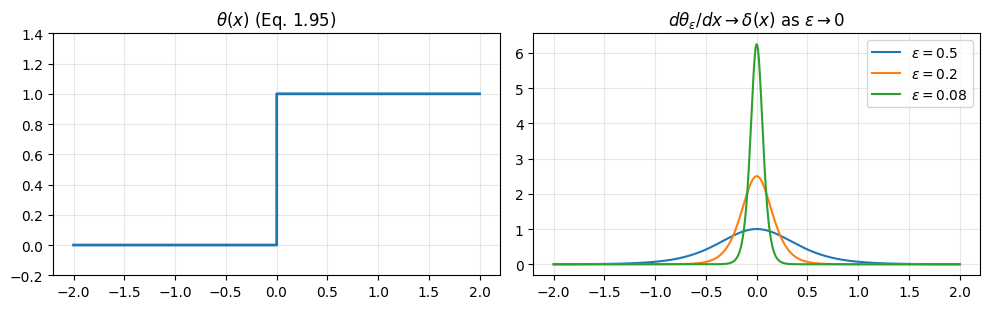

In [23]:
# visual: theta(x) and a nascent delta (its smoothed derivative) sharpening up
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(-2, 2, 1000)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].step(xs, (xs > 0).astype(float), where="post", lw=2)
axes[0].set_title(r"$\theta(x)$ (Eq. 1.95)"); axes[0].set_ylim(-0.2, 1.4)
for eps in (0.5, 0.2, 0.08):
    smooth = 0.5 * (1 + np.tanh(xs / eps))          # smoothed step
    axes[1].plot(xs, np.gradient(smooth, xs), label=rf"$\epsilon={eps}$")
axes[1].set_title(r"$d\theta_\epsilon/dx \to \delta(x)$ as $\epsilon\to 0$")
axes[1].legend()
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## §10 Connections back to this repo's research

- **Separation vector → Green's functions → phase retrieval.** $\nabla(1/\mathscr r)$ is the
  Coulomb kernel; convolving sources against $1/\mathscr r$ is exactly the structure of the
  free-space propagator used in `gs_core.py` — dispersion in the time-domain GS loop *is* a
  convolution with a known kernel, evaluated by FFT.
- **$\delta(x)$ → impulse response → neural operators.** A Green's function is "the field of a
  $\delta$-source"; learning the kernel instead of deriving it is precisely what the FNO in
  `gs_fno.py` does (the Griffiths → ML axis: $\delta$/Green's function $\leftrightarrow$ spectral
  convolution layer).
- **$\theta(x)$ and $\delta'$.** Thresholding ($\theta$) and edge detection ($\delta$-like
  derivatives) are the 1-D ancestors of the rogue-wave trigger logic in `gs_monitor.py`.
- **Parity & handedness → chirality in photonics.** Whether a quantity survives inversion decides
  what can couple to what: optical activity, chiral metasurfaces, and the sign conventions in the
  `pic_design*` layouts all inherit from the same $\det P = -1$ bookkeeping. $\mathbf B$ being a
  pseudovector is why magneto-optic isolators need a handedness-breaking element.

*Worked in this notebook:* 1.13 (a–c), 1.21 (i, iv, v), 1.22 (a–c), 1.23 (ii, vi), 1.24, 1.25 (a–c),
1.45 (a–d), 1.46 (a–b). Problem 1.10 lives in `griffiths_1p10_pseudovectors.ipynb`.